# Why Deep Learning?

Imagine coloring points on a page: blue inside a circle and red outside. We want a model to learn which color a new point should receive. The interesting part is how we describe the point to the model.

We will compare raw coordinates, a distance feature we design ourselves, and intermediate features learned by a small neural network. Seeing all three on the same task will explain why learned representations can help—and why a simpler model can still be enough.

The [notes](01_Why_Deep_Learning_Notes.ipynb) develop the intuition step by step. This companion includes everything needed to follow and run its experiment independently. It is a demonstration of representations, not a claim that a circle requires a deep model.

Run all cells from a fresh Python kernel in order. The [README](README.md) explains how to install Python dependencies: PyTorch, NumPy, and Matplotlib. Everything runs on CPU with locally generated data, without dataset downloads or credentials.

## Start with the problem this lesson solves

Suppose a sensor reports a point's two coordinates, and we must say whether it is outside a circular safe zone. The input is two numbers, $x_1,x_2$; the target is zero inside and one outside. A straight decision boundary cannot surround the center while labeling the whole outside differently.

An **artificial neural network (ANN)** can build intermediate features and combine them into a nonlinear decision. This matters when the useful features are not already known. If we already know the circle's equation, a direct calculation is simpler. Deep learning is useful because it can learn representations from examples, not because every problem needs a large model.

## Follow a small example from coordinates to a decision

**First solve it with a known feature.** For a unit circle, compute $r^2=x_1^2+x_2^2$ and predict one when $r^2>1$.

| Point | Square the coordinates | Add | Decision |
| --- | --- | --- | --- |
| $(0.3,0.4)$ | $0.09,0.16$ | $0.25$ | Inside: zero |
| $(0.8,0.8)$ | $0.64,0.64$ | $1.28$ | Outside: one |
| $(-0.8,-0.8)$ | $0.64,0.64$ | $1.28$ | Outside: one |
| $(0,0)$ | $0,0$ | $0$ | Inside: zero |

Squaring is doing an important job: positive and negative coordinates both contribute to distance. Merely adding signed coordinates would cancel some distant points.

**Now inspect a tiny ANN whose weights we choose by hand.** This is an illustration of a nonlinear representation, not the trained network below and not an exact circle detector. Four hidden units compute

$$h=[\max(0,x_1),\max(0,-x_1),\max(0,x_2),\max(0,-x_2)].$$

Each unit first multiplies inputs by weights and then applies ReLU, which replaces negative scores with zero. The output score is $z=h_1+h_2+h_3+h_4-1$. Predict outside when $z>0$.

For $(0.3,0.4)$, the hidden values are $[0.3,0,0.4,0]$, so $z=0.3+0+0.4+0-1=-0.3$: inside. For $(0.8,0.8)$ they are $[0.8,0,0.8,0]$, so $z=0.6$: outside. For $(-0.8,-0.8)$ they are $[0,0.8,0,0.8]$, again giving $z=0.6$. For the origin all hidden values are zero, giving $z=-1$.

The hidden layer has transformed signed coordinates into nonnegative directional evidence. Its sum is $|x_1|+|x_2|$, producing a diamond boundary. At $(0.6,0.6)$ it predicts outside because $z=0.2$, but the circle rule says inside because $r^2=0.72$. More flexible learned features are needed to approximate the circle better.

**Connect a mistake to learning.** If $z=0.2$ and the true class is zero, sigmoid gives $p=1/(1+e^{-0.2})\approx0.549834$. Binary cross-entropy is $-\ln(1-p)\approx0.798139$. Its gradient with respect to the output bias is $p-y=0.549834$. An SGD step of size $0.1$ changes that bias from $-1$ to approximately $-1.0549834$, reducing this example's outside score. Full training updates all learnable weights using many examples; one example's improvement alone is not enough.

## Why these steps help solve the problem

The input tells the network where the point is. Hidden units create adjustable descriptions of that location. The output combines those descriptions into a score; the loss says how inconsistent the score is with the known label; gradients tell an optimizer how to adjust the description and decision together.

The circle experiment compares raw coordinates, a deliberately designed distance feature, and learned features. Held-out results tell us whether a fitted rule works on new points from the same process. They do not imply that a neural network is better than the known geometry rule. Prediction uses learned weights without the target; targets are needed to teach and evaluate the model.

## Connect the explanation to the code

`points.square().sum(dim=1, keepdim=True)` performs the distance calculation one row at a time. `nn.Linear` forms weighted sums plus biases; hidden activations allow the learned model to bend its boundary. The loss and optimizer teach the learned parameters. The hand-built four-unit example above is a separate explanation, so its scores should not be mistaken for the trained model's saved outputs.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import copy
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| NumPy:", np.__version__)
print("Device: CPU")

Python: 3.9.6
PyTorch: 2.2.2 | NumPy: 1.26.4
Device: CPU


## First make one useful feature ourselves

A point has a horizontal and a vertical coordinate. For a circle centered at zero with radius one, squared distance tells us whether it is inside: square each coordinate and add. For `(0.3, 0.4)`, the result is `0.09 + 0.16 = 0.25`, which is below one.

A PyTorch tensor is an array of numbers. Each row below stores one point. `square()` multiplies each coordinate by itself, and `sum(dim=1)` adds across a row. `keepdim=True` preserves a column containing one distance value per point.

The comparison with one produces labels: zero for inside or on the circle, one for outside. These are calculations we chose using geometry. No parameters have been learned yet.

In [2]:
points = torch.tensor([[0.3, 0.4], [0.8, 0.8], [-0.8, -0.8], [0.0, 0.0]])
squared_distance = points.square().sum(dim=1, keepdim=True)
manual_labels = (squared_distance > 1.0).to(torch.int64)
print("Coordinates:", tuple(points.shape), "-> squared distance:", tuple(squared_distance.shape))
print("Point     r²    label")
for name, radius, label in zip("ABCD", squared_distance[:, 0], manual_labels[:, 0]):
    print(f"{name:5s}  {radius.item():5.2f}     {label.item()}")
assert manual_labels[:, 0].tolist() == [0, 1, 1, 0]

Coordinates: (4, 2) -> squared distance: (4, 1)
Point     r²    label
A       0.25     0
B       1.28     1
C       1.28     1
D       0.00     0


## Generate points and separate their roles

We sample 600 inside points and 600 outside points, uniformly in area within a disk of radius $\sqrt{2}$. Squared radius is sampled uniformly within each class; angle is uniform from 0 to $2\pi$. This makes the classes balanced by construction. The target rule remains squared distance greater than 1.

We shuffle each class independently into 60% training, 20% validation, and 20% test. Validation selects checkpoints (saved parameter states); test is reserved for the final comparison. Only training points are plotted now. All coordinates are in the same fixed range, so no fitted preprocessing is needed.

train     : X (720, 2), y (720, 1)
validation: X (240, 2), y (240, 1)
test      : X (240, 2), y (240, 1)


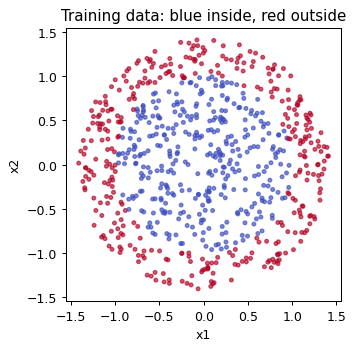

In [3]:
rng = np.random.default_rng(SEED)
n_per_class = 600
radius_squared = np.concatenate([
    rng.uniform(0.0, 1.0, n_per_class),
    rng.uniform(1.0, 2.0, n_per_class),
])
angle = rng.uniform(0.0, 2 * np.pi, 2 * n_per_class)
radius = np.sqrt(radius_squared)
X = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)]).astype(np.float32)
y = (radius_squared > 1.0).astype(np.float32).reshape(-1, 1)

split_ids = {"train": [], "validation": [], "test": []}
for label in (0, 1):
    ids = rng.permutation(np.flatnonzero(y[:, 0] == label))
    for name, part in zip(split_ids, np.split(ids, [360, 480])):
        split_ids[name].extend(part.tolist())

splits = {}
for name, ids in split_ids.items():
    ids = rng.permutation(ids)
    splits[name] = (torch.from_numpy(X[ids]), torch.from_numpy(y[ids]))
    print(f"{name:10s}: X {tuple(splits[name][0].shape)}, y {tuple(splits[name][1].shape)}")
assert not (set(split_ids['train']) & set(split_ids['validation']))
assert not (set(split_ids['train']) & set(split_ids['test']))
assert not (set(split_ids['validation']) & set(split_ids['test']))
assert sum(len(ids) for ids in split_ids.values()) == len(X)
X_train, y_train = splits["train"]
X_val, y_val = splits["validation"]

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train[:, 0], cmap="coolwarm", s=9, alpha=0.65)
ax.set(xlabel="x1", ylabel="x2", title="Training data: blue inside, red outside", aspect="equal")
plt.tight_layout()
plt.show()

## Three representations, one task

`nn.Linear` fits a weighted sum plus an offset (bias). With our binary classification loss, using it on the raw coordinates gives logistic regression. The second model computes squared distance, then fits its output weight and bias. The third learns two intermediate transformations with ReLU, which replaces negative values with zero.

A batch is a group of examples processed together. The network's shape trace is `(batch, 2) → (batch, 16) → (batch, 16) → (batch, 1)`: two input features become intermediate descriptions, then one score. The two hidden layers and their widths are fixed demonstration choices, not settings selected on the test set.

In [4]:
class SquaredRadius(nn.Module):
    def forward(self, x):
        return x.square().sum(dim=1, keepdim=True)

torch.manual_seed(SEED)
models = {
    "Raw coordinates": nn.Linear(2, 1),
    "Designed radius²": nn.Sequential(SquaredRadius(), nn.Linear(1, 1)),
    "Learned features": nn.Sequential(
        nn.Linear(2, 16), nn.ReLU(),
        nn.Linear(16, 16), nn.ReLU(),
        nn.Linear(16, 1),
    ),
}
for name, model in models.items():
    print(f"{name:18s}: {sum(p.numel() for p in model.parameters())} learned parameters")
with torch.no_grad():
    values = X_train[:4]
    print("\nNetwork input:", tuple(values.shape))
    for layer in models["Learned features"]:
        values = layer(values)
        print(f"{type(layer).__name__:8s} -> {tuple(values.shape)}")

Raw coordinates   : 3 learned parameters
Designed radius²  : 2 learned parameters
Learned features  : 337 learned parameters

Network input: (4, 2)
Linear   -> (4, 16)
ReLU     -> (4, 16)
Linear   -> (4, 16)
ReLU     -> (4, 16)
Linear   -> (4, 1)


## Fit the models using training data

A loss measures prediction mismatch. Binary cross-entropy is a loss for binary class probabilities; `BCEWithLogitsLoss` accepts raw scores, called logits, and handles their conversion to probabilities internally. Adam is the optimizer, the procedure that updates model parameters. Gradients describe how parameter changes affect loss; `backward()` computes them.

Each epoch here makes one update using the full training set: clear old gradients, compute loss, calculate gradients, and update parameters. We use 600 epochs and learning rate 0.02, a setting controlling update size. After each update, we measure validation loss without computing gradients and retain the checkpoint with the lowest value. Test data is not passed to this function.

In [5]:
def fit_model(model, epochs=600, learning_rate=0.02):
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train": [], "validation": []}
    best_loss = float("inf")
    best_state = None
    best_epoch = None
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            train_loss = loss_fn(model(X_train), y_train).item()
            val_loss = loss_fn(model(X_val), y_val).item()
        history["train"].append(train_loss)
        history["validation"].append(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
    model.load_state_dict(best_state)
    model.eval()
    assert np.isfinite(history["train"]).all()
    assert np.isfinite(history["validation"]).all()
    return history, best_epoch

histories = {}
for name, model in models.items():
    history, epoch = fit_model(model)
    histories[name] = history
    print(f"{name:18s} | chosen epoch {epoch:3d} | validation loss {min(history['validation']):.4f}")

Raw coordinates    | chosen epoch  22 | validation loss 0.6892
Designed radius²   | chosen epoch 600 | validation loss 0.1260


Learned features   | chosen epoch 384 | validation loss 0.0187


## Inspect learning before opening the test set

Solid lines show training loss; dashed lines show validation loss. A gap can suggest overfitting. A flat, high loss can reflect limited features or optimization problems; use the known geometry to help interpret this example. Curves alone do not prove a model will generalize.

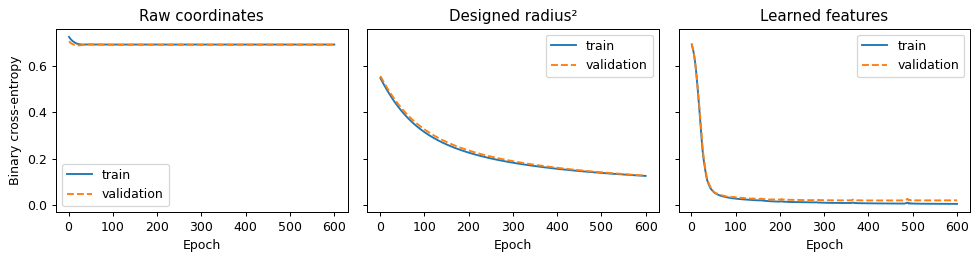

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, (name, history) in zip(axes, histories.items()):
    epochs = np.arange(1, len(history["train"]) + 1)
    ax.plot(epochs, history["train"], label="train")
    ax.plot(epochs, history["validation"], linestyle="--", label="validation")
    ax.set(title=name, xlabel="Epoch")
    ax.legend()
axes[0].set_ylabel("Binary cross-entropy")
plt.tight_layout()
plt.show()

## Final held-out comparison

The checkpoint choices are now fixed. Accuracy counts the fraction of correct labels; a raw score above zero corresponds to a predicted class-1 probability above 0.5. Report training and test accuracy together to avoid confusing fit with generalization. We also show the exact geometry rule, which requires no learned parameters.

Do not use these test results to adjust widths or epochs. If experimenting repeatedly, compare choices on validation data and reserve fresh test data for the final choice.

In [7]:
X_test, y_test = splits["test"]
def accuracy(scores, targets):
    return ((scores > 0).float() == targets).float().mean().item()

print(f"{'Model':18s} {'Train accuracy':>15s} {'Test accuracy':>15s}")
with torch.no_grad():
    for name, model in models.items():
        train_acc = accuracy(model(X_train), y_train)
        test_acc = accuracy(model(X_test), y_test)
        print(f"{name:18s} {train_acc:15.3f} {test_acc:15.3f}")
    rule_acc = accuracy(X_test.square().sum(dim=1, keepdim=True) - 1, y_test)
    print(f"Exact geometry rule: test accuracy = {rule_acc:.3f}")

Model               Train accuracy   Test accuracy
Raw coordinates              0.493           0.521
Designed radius²             0.988           0.992
Learned features             1.000           0.992
Exact geometry rule: test accuracy = 1.000


## Look at the boundary, not just the score

The sigmoid function converts each raw score into a probability estimate between 0 and 1. Colored backgrounds show the estimated probability of being outside; black contours mark probability 0.5. The dashed green circle is the known target boundary, and dots are held-out observations.

The grid visualizes fixed models without fitting them. Its corners extend beyond the sampled disk, where predictions have no test support. Compare the learned boundaries with the dashed circle to see why the accuracy results differ.

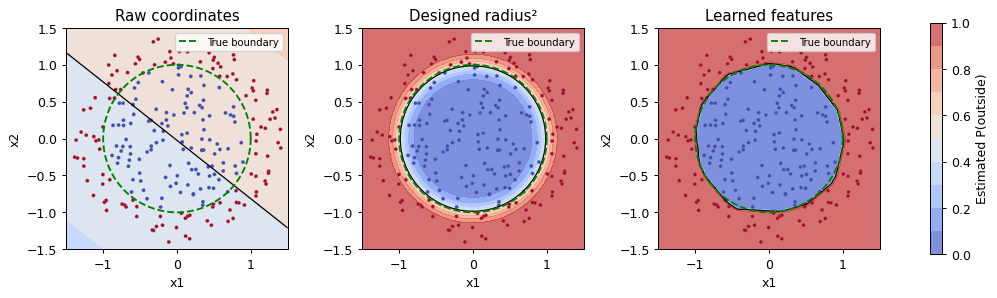

In [8]:
axis = np.linspace(-1.5, 1.5, 120, dtype=np.float32)
gx, gy = np.meshgrid(axis, axis)
grid = torch.from_numpy(np.column_stack([gx.ravel(), gy.ravel()]))
theta = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
with torch.no_grad():
    for ax, (name, model) in zip(axes, models.items()):
        probability = torch.sigmoid(model(grid)).numpy().reshape(gx.shape)
        color_plot = ax.contourf(gx, gy, probability, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.7)
        if probability.min() < 0.5 < probability.max():
            ax.contour(gx, gy, probability, levels=[0.5], colors="black", linewidths=1)
        ax.plot(np.cos(theta), np.sin(theta), "--", color="green", label="True boundary")
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test[:, 0], cmap="coolwarm", vmin=0, vmax=1, s=8, edgecolors="gray", linewidths=0.2)
        ax.set(title=name, xlabel="x1", ylabel="x2", aspect="equal")
        ax.legend(fontsize=8, loc="upper right")
fig.colorbar(color_plot, ax=axes, label="Estimated P(outside)", shrink=0.75)
plt.show()

## Interpreting the saved run

Raw-coordinate logistic regression reached about 52% test accuracy, while both the distance-based model and the neural network reached about 99%. The plots explain the difference: a straight line cannot enclose the inside points, while both other models follow the circular boundary. Small numerical differences can occur across environments.

The network learned a useful transformation without receiving squared distance explicitly, but it did not beat the simpler model supplied with that feature. The exact geometry rule achieved 100% because it is the rule used to generate the labels. These results illustrate why learned representations can help when useful features are hard to design; they do not show that neural networks always win, that depth is necessary here, or that the hidden features equal distance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

capacity = np.linspace(.2, 2.4, 80)
# An illustrative double-descent-shaped test error: approximation falls,
# interpolation makes a peak, then overparameterized interpolation improves.
test_error = .35 + .16 / capacity + .5 * np.exp(-((capacity - 1.05) / .16) ** 2) + .035 * capacity
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(capacity, test_error, color='tab:blue')
ax.axvline(1, color='gray', linestyle='--', label='interpolation threshold')
ax.set(xlabel='Relative model capacity', ylabel='Illustrative test error', title='Bias, variance, and double descent')
ax.legend(); plt.tight_layout(); plt.show()
assert test_error[0] > test_error[-1] and test_error.max() > test_error.min()
print('minimum illustrative error:', float(test_error.min()))